# Buổi 4 — Đọc và vẽ biểu đồ chuỗi thời gian

**Một câu:** một hình chỉ có ích khi đọc nó theo thứ tự cố định và vẽ nó sao cho **không giấu** hay **phóng đại** điều gì.

Tình huống: số lượt thuê xe đạp mỗi giờ ở Washington D.C. có nhịp ngày lồng trong nhịp tuần, nhưng biểu đồ đường thô
17.544 điểm chỉ là một khối màu. Sáu phần dưới dựng dần bộ hình chẩn đoán, và chỉ ra hai kiểu hình nói sai.

| Phần | Câu hỏi |
|---|---|
| 1 | Đọc một hình theo thứ tự nào, tìm ba mẫu hình gì? |
| 2 | Gộp, làm trơn, thang log giấu hay phóng to điều gì? |
| 3 | Làm sao thấy mùa vụ bằng cách xếp dữ liệu theo lịch? |
| 4 | Giờ nào thường đông, giờ nào khó đoán? |
| 5 | "Giờ trước", "hôm qua" hay "tuần trước" giống giờ này nhất? |
| 6 | Hình nói sai bằng cách nào khi không sửa con số nào? |

## 0. Dữ liệu

**Bộ dữ liệu Bike Sharing.** Nhóm tác giả ở Đại học Porto lấy nhật ký mọi lượt thuê của **Capital Bikeshare** — hệ thống xe đạp công cộng ở
Washington D.C., lấy xe ở trạm này, trả ở trạm khác — trong **hai năm 2011–2012**, đếm số lượt theo từng giờ và từng
ngày, rồi ghép thêm thời tiết và lịch nghỉ lễ. Hai bảng: `hour.csv` mỗi dòng là **một giờ** (17.379 dòng), `day.csv`
mỗi dòng là **một ngày** (731 dòng). Số lượt là của **cả hệ thống**, không phải một trạm.

Nguồn: Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894. Giấy phép CC BY 4.0.

| Cột | Nghĩa |
|---|---|
| `cnt` | **số lượt thuê** trong giờ (hoặc ngày) đó — thứ cần dự báo; bằng `casual` (khách vãng lai) + `registered` (hội viên) |
| `dteday`, `hr` | ngày, và giờ trong ngày (0–23; `day.csv` không có `hr`) |
| `yr` | năm: 0 là 2011, 1 là 2012 |
| `weekday`, `workingday` | thứ trong tuần (0 = Chủ nhật, 6 = thứ Bảy); ngày làm việc (1) hay nghỉ — cuối tuần, lễ (0) |
| `weathersit` | thời tiết: 1 quang đãng, 2 sương mù/nhiều mây, 3 mưa nhẹ/tuyết nhẹ, 4 mưa to/bão |
| `temp`, `hum` | nhiệt độ và độ ẩm, đã chia cho giá trị lớn nhất (41 °C, 100%) nên nằm trong 0–1 |

Ô dưới tải dữ liệu (280 KB) một lần rồi kiểm **sha256** — "dấu vân tay" tính từ nội dung tệp, sai một byte là ra chuỗi khác hẳn. Khớp nghĩa là bạn đang có đúng tệp mà mọi con số dưới đây được tính ra.

In [ ]:
import hashlib
import os
import urllib.request
from pathlib import Path

# tên bộ: (sha256, [nơi tải, thử lần lượt])
DU_LIEU = {
    "uci-bike-sharing": ("b70182d0d0508e9abbb79306ce5c0cec34869000f8220175ac83d11dbe845401", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/uci-bike-sharing/bike+sharing+dataset.zip",
        "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip",
    ]),
}
CACHE = Path(os.environ.get("KHOA_FORECASTING_CACHE") or Path.home() / ".cache" / "khoa-forecasting")


def sha256(tep: Path) -> str:
    h = hashlib.sha256()
    with open(tep, "rb") as f:
        for khoi in iter(lambda: f.read(1 << 20), b""):
            h.update(khoi)
    return h.hexdigest()


def lay(ten: str) -> Path:
    """Đường dẫn tệp đã kiểm sha256; chưa có thì tải về một lần."""
    sha, urls = DU_LIEU[ten]
    tep = CACHE / "sha256" / sha[:2] / sha
    if tep.is_file() and sha256(tep) == sha:
        return tep
    tep.parent.mkdir(parents=True, exist_ok=True)
    for url in urls:
        try:
            urllib.request.urlretrieve(url, tep)
            if sha256(tep) == sha:
                return tep
            print("sha256 không khớp:", url)
        except OSError as loi:
            print("tải lỗi:", url, loi)
    raise RuntimeError(f"không tải được {ten} khớp sha256")


for ten in DU_LIEU:
    print(f"{ten:<28} {lay(ten)}")

In [ ]:
import zipfile

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

THU = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]

with zipfile.ZipFile(lay("uci-bike-sharing")) as z:
    h = pd.read_csv(z.open("hour.csv"), parse_dates=["dteday"])
h["ds"] = h["dteday"] + pd.to_timedelta(h["hr"], unit="h")
luoi = pd.date_range(h["ds"].min(), h["ds"].max(), freq="h", name="ds")          # lưới giờ đầy đủ
df = h.set_index("ds")[["cnt", "casual", "temp", "workingday"]].reindex(luoi)     # giờ thiếu → NaN, không phải 0
df["gio"], df["thu"], df["nam"] = df.index.hour, df.index.dayofweek, df.index.year  # thu: 0 = thứ Hai
df["workingday"] = df["workingday"].fillna(df.groupby(df.index.normalize())["workingday"].transform("first"))
thieu = df["cnt"].isna()
print(f"{len(df):,} giờ trên lưới, thiếu {thieu.sum()} giờ, rải trên {df.index[thieu].normalize().nunique()} ngày")

Viết tắt dùng suốt buổi: **T2 … T7** là thứ Hai … thứ Bảy, **CN** là Chủ nhật. Cột `thu` lấy từ `dayofweek` nên
0 là thứ Hai — khác cột `weekday` của tệp gốc (0 là Chủ nhật).

## 1. Đọc hình theo năm bước và tìm ba mẫu hình

**Vấn đề.** Một hình có hàng nghìn điểm. Nhìn đường rồi kết luận ngay thì dễ bỏ qua đơn vị, trục bắt đầu ở đâu, và
nhầm mẫu hình này với mẫu hình khác.

> **xu hướng** · *trend*
>
> - **Là gì:** mức chung đi lên hoặc đi xuống trong thời gian dài; không cần là đường thẳng.
> - **Ví dụ:** tháng nào của 2012 cũng có nhiều lượt thuê hơn cùng tháng 2011.
> - **Để làm gì:** cho biết mức của tương lai sẽ cao hơn hay thấp hơn quá khứ gần.

> **mùa vụ** · *seasonality*
>
> - **Là gì:** mẫu hình lặp lại sau một **số bước cố định, biết trước**, gắn với lịch: giờ trong ngày, thứ trong tuần, tháng trong năm — không chỉ xuân hạ thu đông.
> - **Ví dụ:** ngày làm việc nào cũng đông lúc 8h và 17h.
> - **Để làm gì:** phần dễ dự báo nhất: biết lịch là biết hình dạng.

> **chu kỳ mùa vụ, m** · *seasonal period*
>
> - **Là gì:** số bước trước khi mẫu mùa vụ lặp lại, ký hiệu $m$.
> - **Ví dụ:** dữ liệu giờ lặp theo ngày: $m$ = 24; theo tuần: $m$ = 168.
> - **Để làm gì:** cho biết nhìn lùi bao nhiêu bước để gặp "cùng thời điểm" lần trước.

> **chu kỳ** · *cycle*
>
> - **Là gì:** lên xuống kéo dài, thường vài năm, **độ dài không cố định**, không biết trước.
> - **Ví dụ:** kinh tế tăng 6 năm rồi suy thoái; lần sau tăng 9 năm.
> - **Để làm gì:** tách khỏi mùa vụ: mùa vụ đoán trước được theo lịch, chu kỳ thì không.
>
> 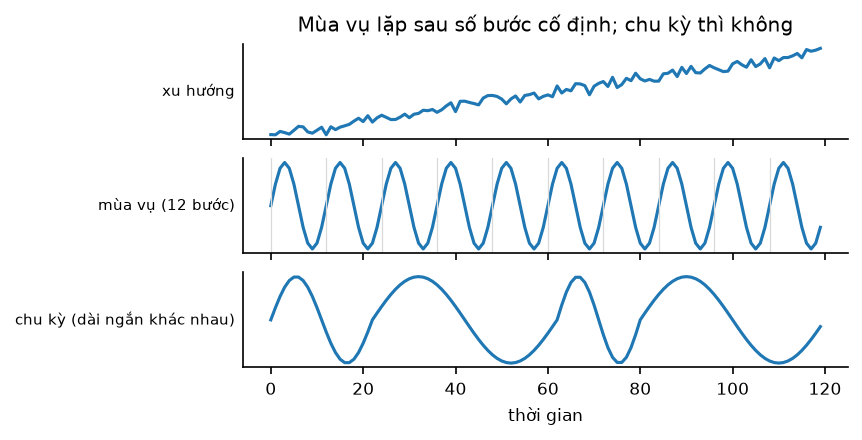

**Lý do.** Đọc mọi hình theo năm bước: **trục ngang → trục dọc (đơn vị, bắt đầu từ đâu) → ký hiệu → chỗ cần nhìn → một câu
kết luận có chỗ và số**. Câu kết luận đó cũng là tiêu đề nên đặt cho hình. Ba thứ cần tìm: xu hướng, mùa vụ, chu kỳ.

**Kết quả.** Hai tuần tính tay (trăm lượt/ngày): trừ mỗi ngày cho trung bình tuần của nó thì phần còn lại của hai tuần
**giống hệt nhau** — đó là mùa vụ tuần; trung bình tuần đi 10 → 12 là xu hướng.

In [ ]:
tuan = np.array([[10, 12, 12, 12, 14, 6, 4],
                 [12, 14, 14, 14, 16, 8, 6]])
tb = tuan.mean(axis=1, keepdims=True)
print("trung bình tuần:", tb.ravel())
print("lệch khỏi trung bình tuần:\n", tuan - tb)

Trên dữ liệu thật, cùng một chuỗi vẽ ở ba mức gộp:

In [ ]:
ngay = df["cnt"].resample("D").sum(min_count=12)     # ngày dưới 12 giờ số liệu → NaN, không cộng ra tổng thấp giả
thang = df["cnt"].resample("MS").sum()
fig, truc = plt.subplots(3, 1, figsize=(9, 6))
tieu_de = ["Theo giờ: một khối màu, chỉ thấy 'hè cao hơn'",
           "Theo ngày: thấy dao động trong tuần và những ngày rơi sát 0",
           "Theo tháng: mượt, có xu hướng và mùa vụ năm — mất nhịp ngày, tuần, ngày bất thường"]
for ax, s, dv, td in zip(truc, [df["cnt"], ngay, thang], ["lượt / giờ", "lượt / ngày", "lượt / tháng"], tieu_de,
                             strict=True):
    ax.plot(s.index, s.to_numpy(), lw=0.3 if len(s) > 1000 else 1)
    ax.set(ylim=(0, None), ylabel=dv, title=f"{td} ({len(s):,} điểm)")
fig.tight_layout()
plt.show()
print("ba ngày thấp nhất:", {f"{k:%d/%m/%Y}": int(v) for k, v in ngay.nsmallest(3).items()})

Ô dưới: bướu hè 2012 cao hơn bướu hè 2011 (xu hướng), hè cao đông thấp (mùa vụ năm). Hai năm dữ liệu quá ngắn để nói
về chu kỳ. Nhịp ngày và nhịp tuần phải tìm bằng hình khác: ô trên là khối màu, ô dưới đã gộp mất chúng.

**Bài học.** Tiêu đề hình là một câu kết luận ("Theo tháng: … mất nhịp ngày"), không phải tên biến ("cnt"). Lặp sau đúng
số bước biết trước là mùa vụ; độ dài mỗi lần một khác là chu kỳ.

## 2. Gộp và làm trơn xoá ngày bất thường; thang log đổi câu hỏi

**Vấn đề.** Ba cách "làm hình dễ nhìn" hay dùng nhất — gộp, làm trơn, thang log — đều bỏ hoặc phóng to một phần thông tin.

> **gộp tần suất** · *temporal aggregation*
>
> - **Là gì:** cộng (hoặc lấy trung bình) nhiều mốc nhỏ thành một mốc lớn hơn.
> - **Ví dụ:** 24 giờ → 1 ngày; 17.544 điểm giờ thành 731 điểm ngày.
> - **Để làm gì:** chọn độ chi tiết hợp câu hỏi — nhưng mức gộp càng thô càng mất chi tiết.

> **làm trơn, trung bình trượt** · *smoothing, moving average*
>
> - **Là gì:** thay mỗi điểm bằng trung bình của nó với các điểm lân cận, cho đường mượt hơn.
> - **Ví dụ:** 50, 52, 48, **2**, 51, 49, 50: trung bình 3 ngày quanh số 2 là (48 + 2 + 51) / 3 = 33,7; cửa sổ 7 ngày ra 43,1.
> - **Để làm gì:** thấy mức chung qua lớp nhiễu — với điều kiện vẽ đè lên dữ liệu gốc, không thay nó.
>
> 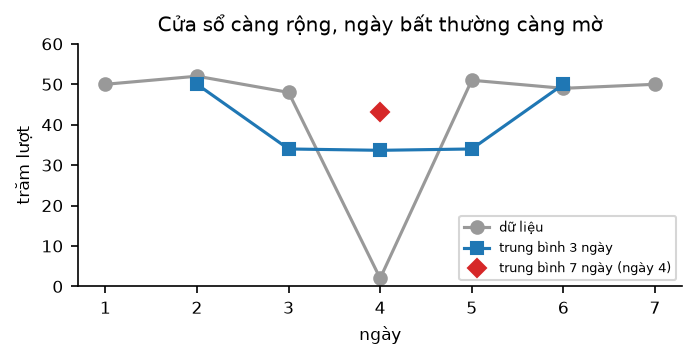

> **thang log** · *log scale*
>
> - **Là gì:** trục dọc đặt mỗi điểm ở độ cao $\log_{10} y$, nên khoảng cách bằng nhau nghĩa là **nhân** cùng một số.
> - **Ví dụ:** 100 → 200 và 200 → 400 cao bằng nhau (cùng gấp đôi); 400 → 500 chỉ cao 1/3 bước đó.
> - **Để làm gì:** đọc tốc độ tăng theo phần trăm (giá, tăng trưởng) thay vì tăng tuyệt đối.
>
> 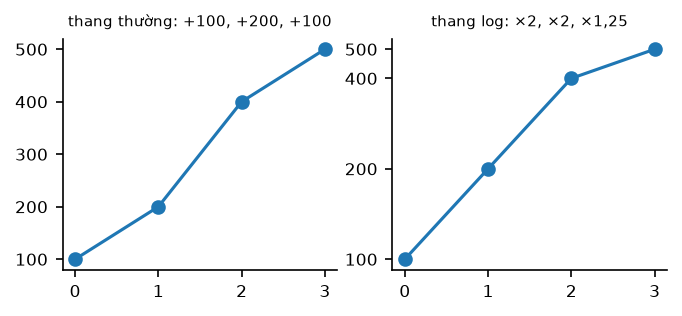

**Lý do.** Trung bình trượt chia một ngày bất thường cho cả cửa sổ, nên cửa sổ càng rộng chỗ lõm càng nông. Thang log đo
bước theo tỷ lệ, nên đoạn tăng nhiều lượt nhất chưa chắc là đoạn tăng nhanh nhất theo phần trăm.

**Kết quả.** Ngày 29/10/2012 bão Sandy, tệp chỉ còn 1 giờ số liệu:

In [ ]:
ngay1 = df["cnt"].resample("D").sum(min_count=1)
tron = ngay1.rolling(7, center=True, min_periods=4).mean()
print(f"29/10/2012: tổng ngày {ngay1['2012-10-29']:.0f} lượt | trung bình trượt 7 ngày {tron['2012-10-29']:,.0f}")

fig, ax = plt.subplots(figsize=(9, 2.8))
doan = slice("2012-09-15", "2012-11-30")
ax.plot(ngay1[doan], "o-", color="0.6", ms=3, label="tổng theo ngày")
ax.plot(tron[doan], color="tab:orange", lw=2, label="trung bình trượt 7 ngày")
ax.set(ylim=(0, None), ylabel="lượt / ngày", title="Làm trơn biến ngày bão gần như trống thành một chỗ lõm nhẹ")
ax.legend(fontsize=8, loc="lower right")
plt.show()

Đường cam ở ngày đó vẫn hơn 4.600 lượt: ai chỉ xem đường làm trơn sẽ không biết có một ngày gần như trống. Còn thang
log, trên tổng tháng năm 2011:

In [ ]:
th11 = df["cnt"].resample("MS").sum()["2011"]
print(pd.DataFrame({"tăng (lượt)": th11.diff(), "tăng (%)": th11.pct_change() * 100})
      .loc["2011-04":"2011-05"].set_axis(["T3→T4", "T4→T5"]).round(1))

fig, (a, b) = plt.subplots(1, 2, figsize=(10, 2.8))
for ax in (a, b):
    ax.plot(th11.index, th11.to_numpy(), "o-")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m"))
a.set(ylim=(0, None), ylabel="lượt / tháng", title="Thang thường: T4→T5 dốc nhất (tăng nhiều lượt nhất)")
b.set(yscale="log", title="Thang log: T3→T4 dốc nhất (tăng nhanh nhất theo %)")
plt.show()

Tháng 4 → 5 thêm nhiều lượt nhất (+40.951), nhưng tháng 3 → 4 tăng nhanh nhất theo phần trăm (+48,1% so với +43,2%).

**Bài học.** Vẽ đường trơn **đè lên** dữ liệu gốc, không thay nó; xem thêm ít nhất một mức gộp chi tiết hơn mức định báo
cáo. Thang log khi hỏi "tăng nhanh cỡ nào (%)", thang thường khi hỏi "cần thêm bao nhiêu xe".

## 3. Xếp dữ liệu theo lịch: cuối tuần khác ngày làm việc ở hình dạng, không ở tổng

**Vấn đề.** Biểu đồ đường vẽ theo thời gian trôi. Muốn thấy mùa vụ phải vẽ theo **vị trí trong vòng lặp**: thứ mấy, giờ mấy.

> **seasonal plot**
>
> - **Là gì:** mỗi vòng lặp (mỗi tuần) vẽ một đường, chồng lên nhau trên cùng trục "vị trí trong vòng lặp".
> - **Ví dụ:** 106 tuần, mỗi tuần một đường từ T2 0h tới CN 23h.
> - **Để làm gì:** thấy hình dạng mùa vụ, và vòng nào lệch khỏi khuôn chung.

> **subseries plot** · *seasonal subseries plot*
>
> - **Là gì:** mỗi "mùa" (mỗi tháng, mỗi thứ) một ô nhỏ chứa các giá trị của riêng mùa đó qua thời gian, kèm vạch trung bình.
> - **Ví dụ:** ô "tháng 3": các ngày tháng 3/2011 rồi tháng 3/2012.
> - **Để làm gì:** thấy từng mùa đổi thế nào qua các năm — ví dụ tháng 12 năm nay có thấp bất thường không.
>
> 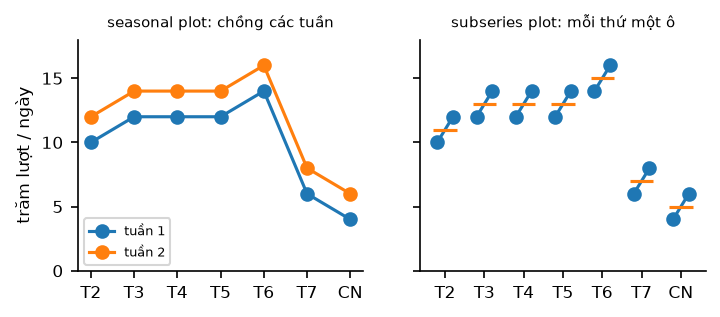

> **mùa vụ kép** · *multiple seasonality*
>
> - **Là gì:** chuỗi có hai mùa vụ trở lên cùng lúc, cái ngắn lồng trong cái dài.
> - **Ví dụ:** lượt thuê: nhịp ngày (24 giờ) lồng trong nhịp tuần (168 giờ) — ngày làm việc hai đỉnh, cuối tuần một bướu.
> - **Để làm gì:** mô hình chỉ học nhịp 24 giờ sẽ dự báo thứ Bảy giống thứ Hai.
>
> 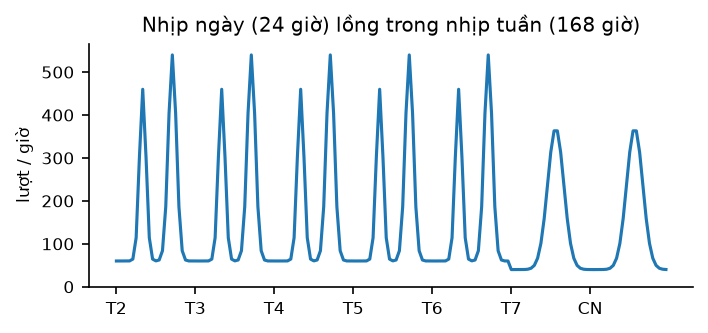

**Lý do.** Với dữ liệu giờ, vị trí trong tuần là **giờ trong tuần** = thứ × 24 + giờ, từ 0 (T2 0h) tới 167 (CN 23h); T3 8h là
1 × 24 + 8 = 32. Xoay bảng cho mỗi tuần một cột rồi vẽ mỗi cột một đường.

**Kết quả.**

In [ ]:
bang = (df.assign(gio_tuan=df["thu"] * 24 + df["gio"], tuan=df.index.to_period("W-SUN"))
          .pivot_table(index="gio_tuan", columns="tuan", values="cnt"))
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(bang.index, bang.to_numpy(), color="0.5", lw=0.3, alpha=0.3)
ax.plot(bang.index, bang.median(axis=1).to_numpy(), color="tab:orange", lw=1.5)
ax.set_xticks(range(0, 168, 24), THU)
ax.set(ylim=(0, None), ylabel="lượt / giờ", title=f"{bang.shape[1]} tuần chồng nhau: T2–T6 hai đỉnh, T7–CN một bướu")
plt.show()

du = df["cnt"].resample("D").agg(["sum", "count"])
du = du[du["count"] == 24]                                   # chỉ ngày đủ 24 giờ
print(f"{len(du)} ngày đủ 24 giờ — lượt/ngày trung bình theo thứ:")
print(du.groupby(du.index.dayofweek)["sum"].mean().set_axis(THU).round(0).astype(int).to_dict())

Cuối tuần chỉ thấp hơn ngày làm việc vài phần trăm (T7 4.653 so với T6 4.933): nhu cầu cuối tuần không mất đi mà đổi
**hình dạng** trong ngày — đó là mùa vụ kép. Subseries theo tháng trả lời câu khác: mỗi tháng đổi thế nào qua hai năm.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 2.8))
for m in range(1, 13):
    v = ngay[ngay.index.month == m].to_numpy()
    x = m - 1 + np.linspace(0.05, 0.85, v.size)
    ax.plot(x, v, lw=0.5, color="tab:blue")
    ax.hlines(np.nanmean(v), m - 0.95, m - 0.15, color="tab:orange")
ax.set_xticks(np.arange(12) + 0.45, [f"Th{m}" for m in range(1, 13)])
ax.set(ylim=(0, None), ylabel="lượt / ngày", title="Mỗi ô một tháng (2011 rồi 2012): tháng nào cũng nhảy bậc sang 2012")
plt.show()
ti_le = (thang["2012"].to_numpy() / thang["2011"].to_numpy())
print(f"tổng tháng 2012 / cùng tháng 2011: từ {ti_le.min():.2f} tới {ti_le.max():.2f} lần")

**Bài học.** Seasonal plot chồng các vòng lặp để thấy hình dạng mùa vụ; subseries plot gom từng mùa vào một ô để thấy mùa
đó đổi qua thời gian. Bẫy khi đọc subseries: bước nhảy **giữa** ô là ranh giới hai năm, không phải lượt thuê tăng dần trong
tháng. (`statsmodels` có `month_plot` nhưng chỉ nhận dữ liệu tháng hoặc quý — với dữ liệu giờ thì tự dựng như trên.)

## 4. Heatmap cho mức thường gặp, boxplot cho độ tản

**Vấn đề.** 106 đường chồng nhau thì rối. Cần một hình cho "thứ nào, giờ nào thường đông", và biết giờ nào **khó đoán**.

> **heatmap**
>
> - **Là gì:** bảng số tô màu: ô càng sáng giá trị càng lớn.
> - **Ví dụ:** 7 dòng thứ × 24 cột giờ, ô (T2, 8h) là trung bình lượt thuê của mọi 8h thứ Hai.
> - **Để làm gì:** một hình duy nhất cho "mỗi thứ, mỗi giờ thường có bao nhiêu" — thấy ngay mùa vụ kép.

> **boxplot** · *box plot*
>
> - **Là gì:** hộp đi từ quantile 0,25 tới 0,75, vạch giữa là trung vị; hai **râu** chỉ tới giá trị xa nhất còn cách mép hộp không quá 1,5 lần độ dài hộp.
> - **Ví dụ:** 5 thứ Hai lúc 8h: 420, 60, 450, 410, 440 → hộp 410–440, vạch 420; ngày lễ 60 nằm xa ngoài hộp.
> - **Để làm gì:** cho độ tản, thứ heatmap (chỉ có trung bình) không cho: hộp rộng là giờ khó dự báo.
>
> 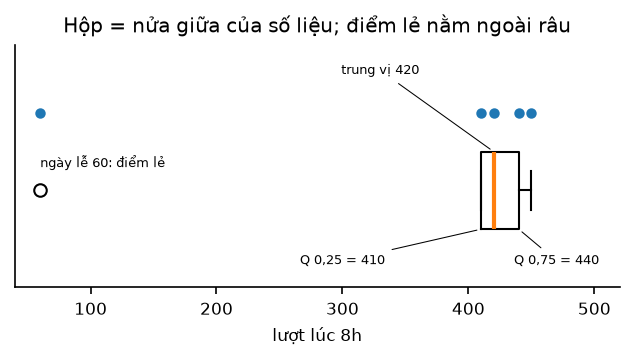

> **IQR** · *interquartile range*
>
> - **Là gì:** khoảng tứ phân vị — độ dài của hộp: quantile 0,75 trừ quantile 0,25.
> - **Ví dụ:** 440 − 410 = 30.
> - **Để làm gì:** đo độ tản mà không bị vài ngày lạ kéo lệch như độ lệch chuẩn.

**Lý do.** Heatmap tô **trung bình** từng ô, mà trung bình bị một ngày lạ kéo lệch: năm thứ Hai 420, 60, 450, 410, 440 có trung
bình 356, thấp hơn 4 trong 5 ngày. Boxplot dùng trung vị và quantile nên cho thấy cả mức lẫn độ tản.

**Kết quả.**

In [ ]:
x = np.array([420, 60, 450, 410, 440])
print("trung bình:", x.mean(), "| quantile 0,25 / 0,5 / 0,75:", np.quantile(x, [0.25, 0.5, 0.75], method="inverted_cdf"))

ho_so = df.pivot_table(index="thu", columns="gio", values="cnt", aggfunc="mean")    # 7 thứ × 24 giờ
fig, ax = plt.subplots(figsize=(9, 2.8))
anh = ax.imshow(ho_so.to_numpy(), aspect="auto", cmap="viridis")
ax.set_yticks(range(7), THU)
ax.set(xlabel="giờ", title="Giờ × thứ: 8h và 17h chỉ sáng vào ngày làm việc")
plt.colorbar(anh, ax=ax, label="lượt / giờ (TB)")
plt.show()
print(ho_so.loc[[0, 2, 5, 6], [8, 13]].set_axis(["T2", "T4", "T7", "CN"]).round(0))

Lúc 8h ngày làm việc gấp nhiều lần cuối tuần (T2 412, CN 84); lúc 13h ngược lại, cuối tuần gấp khoảng đôi. Nhu cầu cuối
tuần **dời giờ**. Boxplot theo giờ, tách ngày làm việc và ngày nghỉ:

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3))
for lam, lech, mau, ten in ((1, -0.2, "tab:blue", "ngày làm việc"), (0, 0.2, "tab:orange", "ngày nghỉ")):
    phan = df[df["workingday"] == lam]
    hop = ax.boxplot([phan.loc[phan["gio"] == g, "cnt"].dropna() for g in range(24)], positions=np.arange(24) + lech,
                     widths=0.35, patch_artist=True, showfliers=False, manage_ticks=False)
    for p in hop["boxes"]:
        p.set(facecolor=mau, alpha=0.6)
    ax.plot([], [], color=mau, lw=6, label=ten)
ax.set_xticks(range(0, 24, 3))
ax.set(xlabel="giờ", ylabel="lượt / giờ", title="Ngày nghỉ đỉnh trưa, ngày làm việc đỉnh 8h và 17h — 17h tản nhất")
ax.legend(fontsize=8)
plt.show()

for lam, g in [(1, 8), (1, 17), (0, 8), (0, 13)]:
    q = df.loc[(df["workingday"] == lam) & (df["gio"] == g), "cnt"].quantile([0.25, 0.5, 0.75])
    print(f"{'làm việc' if lam else 'nghỉ    '} {g:>2}h: trung vị {q[0.5]:.0f}, hộp {q[0.25]:.0f}–{q[0.75]:.0f}")

Lúc 8h hộp ngày nghỉ (57–141) nằm hẳn dưới hộp ngày làm việc (365–646): "làm việc hay nghỉ" là thông tin bắt buộc khi dự
báo giờ đó. Hộp 17h ngày làm việc rộng nhất, khoảng 356 lượt.

**Bài học.** Heatmap cho mức thường gặp của từng ô lịch trên một hình; boxplot cho độ tản. Chênh 52 lượt giữa hai ô heatmap
chưa nói lên gì khi riêng một hộp đã rộng 356 lượt.

## 5. Cùng giờ tuần trước giống giờ này nhất

**Vấn đề.** Dự báo giờ tới thì dựa vào "giờ trước", "cùng giờ hôm qua" hay "cùng giờ tuần trước"?

> **scatter** · *scatter plot*
>
> - **Là gì:** biểu đồ phân tán: mỗi điểm là một cặp (x, y); nhìn hình dạng đám điểm để thấy quan hệ.
> - **Ví dụ:** x = nhiệt độ ngày, y = lượt thuê ngày: đám điểm đi lên là trời ấm thì đông khách.
> - **Để làm gì:** thấy quan hệ có thẳng không, có mấy nhóm, có điểm lạ không — thứ một hệ số $r$ không nói.

> **lag plot**
>
> - **Là gì:** biểu đồ trễ — scatter của $y_t$ theo $y_{t-k}$: mỗi điểm là (giá trị $k$ bước trước, giá trị bây giờ).
> - **Ví dụ:** chuỗi 2, 4, 6, 4, 2, 4, 6, 4 với trễ 2 cho 6 cặp (2, 6), (4, 4), (6, 2), … nằm trên đường đi xuống.
> - **Để làm gì:** đám điểm bám đường chéo ở trễ $k$ nghĩa là giá trị cách $k$ bước đoán tốt giá trị bây giờ.
>
> 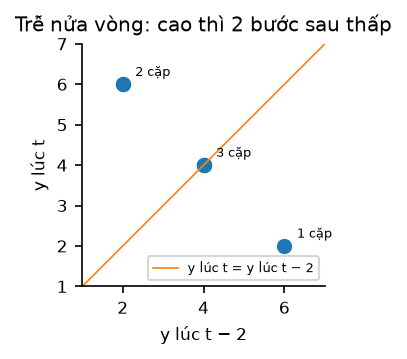

> **ACF** · *autocorrelation function*
>
> - **Là gì:** hàm tự tương quan: dãy $r_1, r_2, r_3, \dots$ vẽ theo độ trễ $k$ — mỗi $r_k$ đo chuỗi giống chính nó dời lùi $k$ bước tới đâu.
> - **Ví dụ:** chuỗi 2, 4, 6, 4 lặp lại: $r_2 = -0{,}75$ (nửa vòng), $r_4 = 0{,}5$ (một vòng).
> - **Để làm gì:** đỉnh của ACF chỉ ra chu kỳ mùa vụ, và độ trễ nào đáng dùng làm đầu vào dự báo.
>
> 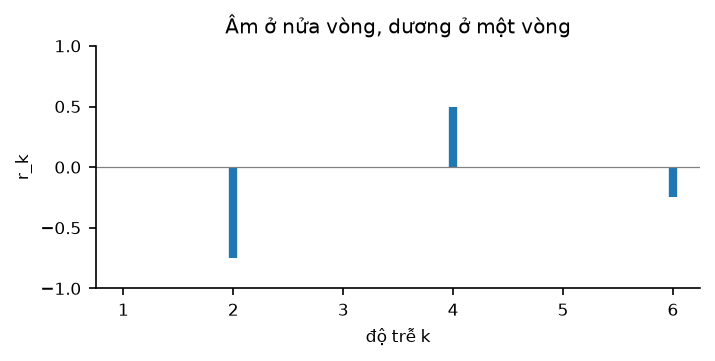

**Lý do.** Công thức tự tương quan cộng các tích "độ lệch bây giờ × độ lệch $k$ bước trước" rồi chia cho tổng bình phương độ
lệch của cả chuỗi:

$$r_k = \frac{\sum_{t=k+1}^{T} (y_t - \bar y)(y_{t-k} - \bar y)}{\sum_{t=1}^{T} (y_t - \bar y)^2}$$

Hai điểm cùng phía trung bình cho tích dương, khác phía cho tích âm. Trễ bằng một vòng lặp cho $r$ dương; trễ bằng nửa vòng
ghép đỉnh với đáy nên $r$ âm.

**Kết quả.**

In [ ]:
def acf_nhanh(y, so_tre):
    y = np.asarray(y, dtype=float)
    lech = y - np.nanmean(y)
    mau = np.nansum(lech**2)
    return np.array([1.0] + [np.nansum(lech[k:] * lech[:-k]) / mau for k in range(1, so_tre + 1)])  # bỏ cặp có NaN


print("chuỗi 2,4,6,4 lặp:", acf_nhanh([2, 4, 6, 4, 2, 4, 6, 4], 4).round(2))

fig, truc = plt.subplots(1, 4, figsize=(11, 3))
for o, k in zip(truc, (1, 12, 24, 168), strict=True):
    cap = pd.DataFrame({"truoc": df["cnt"].shift(k), "sau": df["cnt"]}).dropna()
    o.scatter(cap["truoc"], cap["sau"], s=0.5, alpha=0.1)
    o.plot([0, 1000], [0, 1000], color="tab:orange", lw=0.8)
    o.set(xlim=(0, 1000), ylim=(0, 1000), aspect="equal", xlabel=f"lượt lúc t − {k} giờ",
          title=f"trễ {k}: r = {cap.corr().iloc[0, 1]:.3f}")
truc[0].set_ylabel("lượt lúc t")
fig.suptitle("Trễ 168 bám đường chéo nhất, trễ 12 tản thành hai nhánh")
plt.show()

Chuỗi nhỏ cho đúng $r_2 = -0{,}75$, $r_4 = 0{,}5$ như tính tay. Trên dữ liệu thật, cùng giờ tuần trước (trễ 168) cho đám
điểm hẹp nhất. Ô trễ 12 có hai nhánh đổ theo hai trục (đông sáng ghép vắng đêm), nên $r$ âm nhẹ chỉ là trung bình của hai
nhánh, không phải "quan hệ âm" dùng được. ACF cho cả dãy $r_k$ trong một hình:

In [ ]:
r = acf_nhanh(df["cnt"], 336)
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.vlines(range(337), 0, r, lw=0.8)
dai = 1.96 / np.sqrt(df["cnt"].notna().sum())
ax.axhspan(-dai, dai, color="0.7", alpha=0.5)
for k in (24, 168, 336):
    ax.axvline(k, color="tab:orange", lw=0.6, ls="--")
ax.set(xlabel="độ trễ k (giờ)", ylabel="r_k", title="Đỉnh mỗi 24 giờ; đỉnh 168 cao hơn hàng xóm — mùa vụ ngày lồng mùa vụ tuần")
plt.show()
print({k: round(float(r[k]), 3) for k in (12, 24, 144, 168, 336)}, f"| dải ±{dai:.3f}")

Đỉnh một tuần (0,864) cao hơn đỉnh sáu ngày ngay trước nó (0,786): cùng giờ, cùng thứ mới là "người giống nhất". Dải
xám là vùng mà $r_k$ của một chuỗi hoàn toàn ngẫu nhiên thường rơi vào; với 17.379 giờ nó chỉ rộng ±0,015, nên gần như vạch
nào cũng vượt. $r_{168}$ của ACF hơi khác $r$ của lag plot (0,876) vì ACF dùng trung bình và mẫu số của cả chuỗi.

**Bài học.** Ở dữ liệu dài, **đọc hình dạng** ACF (đỉnh ở đâu, cao thấp ra sao), đừng đếm vạch vượt dải. Trễ bằng bội số chu kỳ
mùa vụ là ứng viên tốt nhất để dự báo.

## 6. Không sửa số nào vẫn làm hình nói sai được

**Vấn đề.** Trục kép, trục y cắt, và trộn nhiều năm vào một scatter đều làm người xem kết luận sai mà dữ liệu vẫn đúng.

> **trục kép** · *dual axis*
>
> - **Là gì:** một hình có hai trục dọc với hai thang khác nhau, trái và phải.
> - **Ví dụ:** trái lượt thuê 1–3 triệu, phải nhiệt độ 20–22 °C: hai đường trùng khít dù một cái tăng 200%, một cái 10%.
> - **Để làm gì:** cần nhận ra: người vẽ chọn thang là chọn được chỗ hai đường gặp nhau.

> **trục y cắt** · *truncated y-axis*
>
> - **Là gì:** trục dọc không bắt đầu từ 0 mà từ một giá trị gần dữ liệu.
> - **Ví dụ:** 490 và 510 triệu vẽ trên trục 480–520: cột thứ hai cao gấp ba cột đầu, dù chỉ tăng khoảng 4%.
> - **Để làm gì:** cần nhận ra: số đếm và tổng phải vẽ từ 0 để độ cao tỷ lệ với giá trị.
>
> 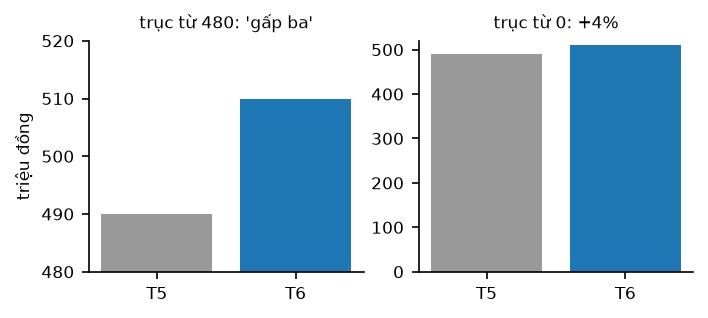

**Lý do.** Một điểm cao bao nhiêu phần chiều cao hình = (giá trị − đáy trục) / (đỉnh trục − đáy trục). Người vẽ chọn đáy và đỉnh
trục thì chọn được độ cao. Nghiên cứu cảm nhận cho thấy trục cắt làm người xem thấy chênh lệch lớn hơn thật, kể cả khi có
ký hiệu báo trục bị cắt.

**Kết quả.** Hình gây hiểu nhầm (trục kép, trục trái cắt ở 90.000) và bản vẽ lại:

In [ ]:
th12 = df[df["nam"] == 2012].resample("MS").agg({"cnt": "sum", "temp": "mean"})
th12["do_c"] = th12["temp"] * 41                     # temp đã chia cho 41 °C

fig, ax = plt.subplots(figsize=(8, 2.6))
ax.plot(th12.index, th12["cnt"], "o-")
ax.set_ylim(90_000, 220_000)
ax2 = ax.twinx()
ax2.plot(th12.index, th12["do_c"], "s-", color="tab:orange")
ax2.set_ylim(5, 32)
ax.set_title("GÂY HIỂU NHẦM: 'Lượt thuê bám sát nhiệt độ'")
plt.show()

fig, (a, b, c) = plt.subplots(1, 3, figsize=(12, 3))
a.plot(th12.index, th12["cnt"], "o-")
a.set(ylim=(0, None), ylabel="lượt / tháng", title="Lượt thuê 2012 (trục từ 0)")
b.plot(th12.index, th12["do_c"], "s-", color="tab:orange")
b.set(ylim=(0, None), ylabel="°C", title="Nhiệt độ trung bình")
for ax in (a, b):
    ax.tick_params(axis="x", labelrotation=45)
c.scatter(th12["do_c"], th12["cnt"])
for t, hang in th12.iterrows():
    c.annotate(t.month, (hang["do_c"], hang["cnt"]), fontsize=7)
r12 = th12["cnt"].corr(th12["temp"])
c.set(ylim=(0, None), xlabel="°C", title=f"Quan hệ: r = {r12:.2f}, nhưng T9 mát mà đông nhất")
fig.tight_layout()
plt.show()
print(f"r theo 12 tháng 2012: {r12:.2f}")

Quan hệ có thật ($r$ = 0,91) nhưng không tăng mãi: tháng 9 mát hơn tháng 7 mà lượt thuê cao nhất năm — trục kép không
cho thấy điều này. Muốn hai chuỗi khác đơn vị chung một trục thì **đánh chỉ số**: chia cho giá trị tháng đầu, nhân 100.

Kiểu sai thứ ba: gộp hai năm vào một scatter theo ngày.

In [ ]:
nd = df.resample("D").agg({"cnt": "sum", "temp": "mean", "nam": "first"}).dropna()
fig, ax = plt.subplots(figsize=(7, 3))
for nam, mau in ((2011, "tab:blue"), (2012, "tab:orange")):
    p = nd[nd["nam"] == nam]
    ax.scatter(p["temp"] * 41, p["cnt"], s=4, color=mau, alpha=0.6, label=str(nam))
ax.set(xlabel="nhiệt độ TB ngày (°C)", ylabel="lượt / ngày", title="Cùng nhiệt độ, 2012 cao hơn 2011")
ax.legend(fontsize=8)
plt.show()
r_nam = {int(n): round(float(g["cnt"].corr(g["temp"])), 3) for n, g in nd.groupby("nam")}
print("r nhiệt độ × lượt/ngày:", r_nam, "| gộp hai năm:", round(nd["cnt"].corr(nd["temp"]), 3))

Gộp hai năm cho $r$ = 0,627, thấp hơn **cả hai** năm riêng (0,771 và 0,714): hai đám mây song song ở hai mức, trộn vào nhau
thì dày theo chiều dọc và quan hệ trông yếu hơn thật.

**Bài học.** Số đếm và tổng vẽ trục từ 0; không dùng trục kép; muốn nói về quan hệ thì vẽ scatter, tô màu theo thời gian, và
tính $r$ từng nhóm.

## 7. Bài tập về nhà — đáp số

**Bài 1 — Chuỗi lạ: khách vãng lai `casual`.** Cùng heatmap và ACF, thay `cnt` bằng `casual`:

In [ ]:
ho_so_c = df.pivot_table(index="thu", columns="gio", values="casual", aggfunc="mean")
print(ho_so_c.loc[[0, 2, 5, 6], [8, 13, 17]].set_axis(["T2", "T4", "T7", "CN"]).round(0))
dc = df["casual"].resample("D").agg(["sum", "count"])
dc = dc[dc["count"] == 24].groupby(dc[dc["count"] == 24].index.dayofweek)["sum"].mean().set_axis(THU).round(0)
print("casual, lượt/ngày TB theo thứ:", dc.astype(int).to_dict())
rc = acf_nhanh(df["casual"], 168)
print("ACF casual trễ 24, 144, 168:", rc[[24, 144, 168]].round(3))

Khách vãng lai **ngược** hẳn `cnt`: không có đỉnh 8h và 17h, cuối tuần đông gấp nhiều lần ngày làm việc — họ đi chơi, không
đi làm. Mùa vụ tuần của `casual` nằm ở **tổng ngày**, còn của `cnt` nằm ở hình dạng trong ngày.

**Bài 2 — Seasonal plot theo năm.** Mỗi năm một đường theo "ngày thứ mấy trong năm", làm trơn 7 ngày cho dễ so:

In [ ]:
fig, ax = plt.subplots(figsize=(9, 2.8))
tron_nam = {}
for nam in (2011, 2012):
    s = ngay1[str(nam)]
    tron_nam[nam] = pd.Series(s.rolling(7, center=True, min_periods=4).mean().to_numpy(), index=s.index.dayofyear)
    ax.plot(s.index.dayofyear, s.to_numpy(), lw=0.4, alpha=0.5)
    ax.plot(tron_nam[nam], lw=1.5, label=str(nam))
ax.set(ylim=(0, None), xlabel="ngày trong năm", ylabel="lượt / ngày", title="2012 trên 2011 gần cả năm; lệch nhiều nhất cuối tháng 1, ngược chiều cuối tháng 12")
ax.legend(fontsize=8)
plt.show()
ti = (tron_nam[2012] / tron_nam[2011]).dropna()
print(f"2012/2011 (trơn 7 ngày): cao nhất {ti.max():.2f} lần ở ngày {ti.idxmax()} (cuối tháng 1), "
      f"thấp nhất {ti.min():.2f} lần ở ngày {ti.idxmin()} (cuối tháng 12)")
print("ba ngày thấp nhất mỗi năm:", {n: [f"{d:%d/%m}" for d in ngay1[str(n)].nsmallest(3).index] for n in (2011, 2012)})

Hai năm lệch nhau rõ nhất ở **cuối tháng 1** (2012 gấp 3,84 lần 2011: tháng 1/2011 có hai ngày thấp nhất năm, 26 và
27/1) và ở **cuối tháng 12**, nơi 2012 lại thấp hơn (0,80 lần: ngày 24 và 26/12/2012 thuộc ba ngày thấp nhất năm). Ngày
29/10/2012 (bão Sandy) cũng hiện thành một vết lõm riêng. Mỗi khoảng lệch đều truy được về vài ngày cụ thể — ngày thời tiết
xấu, ngày lễ hoặc ngày thiếu giờ trong tệp — chứ không phải hai năm có mùa vụ khác nhau.

**Bài 3 — Hai tỷ lệ khung hình**, cùng tổng theo ngày năm 2012:

In [ ]:
s12 = ngay1["2012"]
fig = plt.figure(figsize=(11, 2.8))
a = fig.add_axes([0.0, 0.1, 0.22, 0.8])          # gần vuông
b = fig.add_axes([0.3, 0.35, 0.7, 0.35])        # dẹt, khoảng 8 : 1 theo cảm nhận
for ax in (a, b):
    ax.plot(s12.index, s12.to_numpy(), lw=0.6)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m"))
a.set_title("vuông: thấy xu hướng lên–xuống cả năm", fontsize=8)
b.set_title("dẹt: thấy răng cưa theo tuần và từng ngày rơi", fontsize=8)
plt.show()

Khung vuông làm dốc rõ: mùa xuân tăng, cuối thu giảm. Khung dẹt kéo giãn thời gian nên thấy nhịp tuần và từng ngày bất
thường, nhưng xu hướng trông gần như phẳng. Không khung nào đúng cho mọi câu hỏi — chọn theo điều cần nói.

## Tự kiểm

- [ ] Đọc một hình lạ theo năm bước, kết thúc bằng một câu có chỗ và số.
- [ ] Phân biệt mùa vụ và chu kỳ bằng một câu (số bước cố định hay không).
- [ ] Giải thích vì sao trung bình trượt 7 ngày còn hơn 4.600 lượt ở ngày bão.
- [ ] Nói được heatmap cho gì, boxplot cho thêm gì.
- [ ] Giải thích vì sao lag plot trễ 12 có hai nhánh và $r$ gần 0.
- [ ] Vẽ lại một hình trục kép cho trung thực.